# Volatility — cross-model evaluation

Pulls together the per-model outputs written by `01`–`04` and compares them on a common
footing.

| Model | Notebook | Features |
|---|---|---|
| GARCH(1,1) | `01_garch` | weekly returns (parametric) |
| Naïve | `02_har` | $\text{RV}_{t-1}$ |
| HAR-RV | `02_har` | 3 HAR lags |
| Random Forest | `03_random_forest` | 3 HAR lags |
| XGBoost | `04_xgboost` | 3 HAR lags |

Run `00`–`04` first so their `metrics_*` / `pred_*` / `period_*` CSVs are fresh.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vol_utils import vol_diebold_mariano
import warnings; warnings.filterwarnings('ignore')

PROC   = '../../data/processed'
MODELS = ['garch', 'har', 'rf', 'xgb']

metrics = pd.concat([pd.read_csv(f'{PROC}/metrics_{m}_volatility.csv') for m in MODELS],
                    ignore_index=True)
preds   = {m: pd.read_csv(f'{PROC}/pred_{m}_volatility.csv',
                          parse_dates=['Date']).set_index('Date') for m in MODELS}
print('loaded', len(metrics), 'metric rows from', len(MODELS), 'notebooks')


loaded 5 metric rows from 4 notebooks


## 1. Combined results table

All models on RMSE / MAE / $R^2$ / DCA, sorted by RMSE (lower is better). Saved to
`metrics_volatility_summary.csv`.


In [2]:
metrics_sorted = metrics.sort_values('rmse').reset_index(drop=True)
metrics_sorted.to_csv(f'{PROC}/metrics_volatility_summary.csv', index=False)
metrics_sorted.round(5)


,model,rmse,mae,r2,dca
0,XGB (HAR),0.03133,0.01765,0.32392,0.68966
1,RF (HAR),0.03150,0.01645,0.31649,0.71264
2,HAR-RV,0.03205,0.01627,0.29279,0.70690
3,"GARCH(1,1)",0.03281,0.01802,0.25882,0.67816
4,Naive (RV_t-1),0.03986,0.02014,-0.09429,0.00000


## 2. Sub-period breakdown

Per-year RMSE and DCA for each model (Naïve excluded — it has no `period_*` file of its
own). Saved to `period_volatility_summary.csv`.

Each row reflects the headline variant from its notebook — not the best ablation:
- **GARCH** — GARCH(1,1), the only model in `01_garch`
- **HAR** — bare HAR (3 RV lags: 1w, 4w, 12w)
- **RF / XGB** — three HAR lags only; same information set as OLS-HAR, different estimator

The EXOG/spillover effect is isolated later in the ablation tables, where `HAR+EXOG`, `RF/XGB (HAR+EXOG)`, and the sentiment rungs are compared on matched samples.

In [3]:
period_all = []
for m in MODELS:
    p = pd.read_csv(f'{PROC}/period_{m}_volatility.csv')
    p.insert(0, 'model', m.upper())
    period_all.append(p)
period_all = pd.concat(period_all, ignore_index=True)
period_all.to_csv(f'{PROC}/period_volatility_summary.csv', index=False)
period_all.round(4)

,model,Period,n,RMSE,MAE,DCA
0,GARCH,2023 (choppy),52,0.0162,0.0140,0.6731
1,GARCH,2024 (bull start),52,0.0145,0.0122,0.7885
2,GARCH,2025 (bull run),52,0.0251,0.0194,0.6346
3,GARCH,2026 (YTD),18,0.0850,0.0425,0.5000
4,GARCH,── Full test ──,174,0.0328,0.0180,0.6782
5,HAR,2023 (choppy),52,0.0148,0.0122,0.6923
6,HAR,2024 (bull start),52,0.0146,0.0115,0.7885
7,HAR,2025 (bull run),52,0.0222,0.0155,0.6731
8,HAR,2026 (YTD),18,0.0852,0.0442,0.6111
9,HAR,── Full test ──,174,0.0320,0.0163,0.7069


## 3. 2026 zoom — actual vs each model

Same 2026 sanity-check view as the return notebooks: actual RV in black, each model
overlaid.


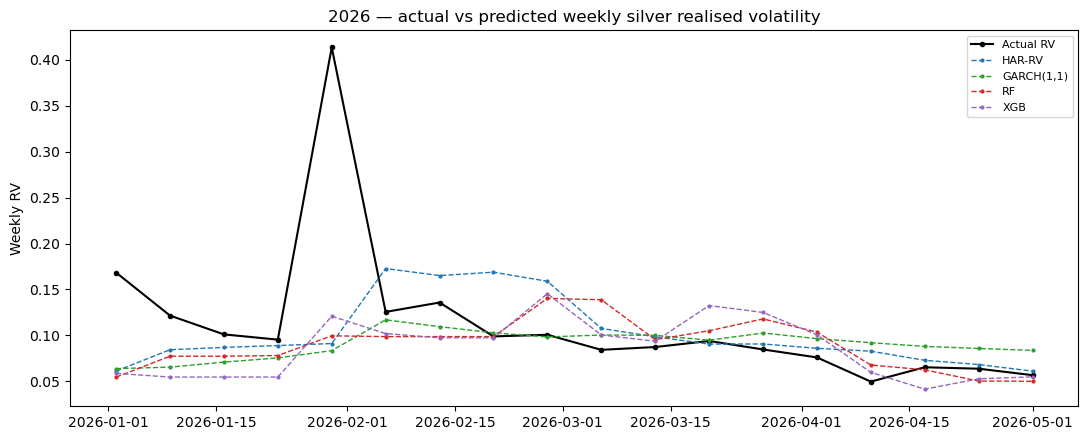

In [4]:
zoom = preds['har'][['actual']].copy()
zoom['Naive']      = preds['har']['naive']
zoom['HAR-RV']     = preds['har']['har']
zoom['GARCH(1,1)'] = preds['garch']['garch']
zoom['RF']         = preds['rf']['rf']
zoom['XGB']        = preds['xgb']['xgb']
zoom = zoom.loc['2026-01-01':]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(zoom.index, zoom['actual'], 'k-', lw=1.5, marker='o', ms=3, label='Actual RV')
for col, c in zip(['HAR-RV', 'GARCH(1,1)', 'RF', 'XGB'],
                  ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']):
    ax.plot(zoom.index, zoom[col], '--', lw=1, marker='.', ms=4, color=c, label=col)
ax.set_title('2026 — actual vs predicted weekly silver realised volatility')
ax.set_ylabel('Weekly RV'); ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


## 4. Diebold-Mariano tests

Each model against the Naïve floor — the Diebold-Mariano (1995) test with
Newey-West (1987) lag-1 variance, via `vol_diebold_mariano` in `vol_utils`. A negative
DM stat means the model has lower loss; the stars show whether the gap is significant.
Naïve is the baseline because it is the smallest possible model.

**The loss function matters here.** Weekly silver RV is extremely heavy-tailed — the
2026 spike weeks carry RV roughly 10× the median. Under **squared-error** loss a single
extreme week can account for ~80 % of the loss differential, which inflates the DM
variance and destroys the test's power even when a model's RMSE is clearly lower. The
volatility-forecasting literature (Patton 2011) therefore compares forecasts under
**QLIKE** — a proxy-robust, ratio-based loss that is far less sensitive to extreme
weeks. QLIKE-DM is reported as the **primary** test below; squared-error DM is kept
underneath as a reference.

The gap between the two is itself informative: a model can be steadily and
significantly better in normal weeks (QLIKE-significant) yet not separable under MSE,
because in the handful of extreme weeks *every* model is about equally wrong.

In [5]:
actual = preds['har']['actual'].values
naive  = preds['har']['naive'].values
model_preds = {'HAR-RV':     preds['har']['har'].values,
               'GARCH(1,1)': preds['garch']['garch'].values,
               'RF':         preds['rf']['rf'].values,
               'XGB':        preds['xgb']['xgb'].values}

dm_rows = []
print('QLIKE loss  --  primary test, robust to the extreme RV weeks:')
for name, p in model_preds.items():
    dm_rows.append(vol_diebold_mariano(actual, p, naive, name, 'Naive', loss='qlike'))

print('\nSquared-error loss  --  reference, dominated by a few tail weeks:')
for name, p in model_preds.items():
    dm_rows.append(vol_diebold_mariano(actual, p, naive, name, 'Naive', loss='mse'))

pd.DataFrame(dm_rows).to_csv(f'{PROC}/dm_volatility_summary.csv', index=False)

QLIKE loss  --  primary test, robust to the extreme RV weeks:
HAR-RV                       vs Naive         [qlike]  DM=-2.970  p=0.003  **    -> winner: HAR-RV
GARCH(1,1)                   vs Naive         [qlike]  DM=-2.682  p=0.007  **    -> winner: GARCH(1,1)
RF                           vs Naive         [qlike]  DM=-2.868  p=0.004  **    -> winner: RF
XGB                          vs Naive         [qlike]  DM=-2.625  p=0.009  **    -> winner: XGB

Squared-error loss  --  reference, dominated by a few tail weeks:
HAR-RV                       vs Naive         [mse  ]  DM=-1.260  p=0.208  (ns)  -> winner: tie
GARCH(1,1)                   vs Naive         [mse  ]  DM=-1.192  p=0.233  (ns)  -> winner: tie
RF                           vs Naive         [mse  ]  DM=-1.237  p=0.216  (ns)  -> winner: tie
XGB                          vs Naive         [mse  ]  DM=-1.089  p=0.276  (ns)  -> winner: tie


## 5. Sentiment ablation — does Reddit sentiment help?

The headline comparison above uses only silver's own volatility history for HAR, RF and
XGB, plus the parametric GARCH benchmark. A separate ablation in `02_har` (§4),
`03_random_forest` (§5) and `04_xgboost` (§5) tests whether **EXOG cross-asset RVs**
and **sentiment** — post-volume *attention* and *sentiment intensity*, built in
`00_features` §5 — carry information about next-week RV beyond the HAR features. The motivation is the news→volatility channel (Engle & Ng 1993); the closest
published precedent is Audrino, Sigrist & Ballinari (2020).

Each family carries its own HAR-feature baseline; the `dm_qlike` / `dm_qlike_p`
columns give the QLIKE-DM stat vs that baseline (negative = the rung is better;
baseline rows are blank). The AR(1) rows are minimal own-history sanity checks; the
`HAR+EXOG` rows test cross-asset spillover; the sentiment rows test attention/tone.
The ablation is scored on the test weeks where Reddit features exist (174 of 175 —
the final 2026 week is dropped), so these RMSEs are not byte-identical to the headline
table above.

In [6]:
# Sentiment ablation — tables gathered from 01 / 03 / 04
sent_files = {'HAR': 'metrics_har_sentiment_volatility.csv',
              'RF':  'metrics_rf_sentiment_volatility.csv',
              'XGB': 'metrics_xgb_sentiment_volatility.csv'}
sent_all = []
for fam, fn in sent_files.items():
    s = pd.read_csv(f'{PROC}/{fn}')
    s.insert(0, 'family', fam)
    sent_all.append(s)
sent_all = pd.concat(sent_all, ignore_index=True)
sent_all.to_csv(f'{PROC}/metrics_sentiment_volatility_summary.csv', index=False)
print('Saved metrics_sentiment_volatility_summary.csv')
sent_all.round(5)

Saved metrics_sentiment_volatility_summary.csv


,family,model,rmse,mae,r2,dca,dm_qlike,dm_qlike_p,dm_mse,dm_mse_p,winner_dm_qlike,winner_dm_mse
0,HAR,HAR,0.03205,0.01627,0.29263,0.70690,NaN,NaN,NaN,NaN,NaN,NaN
1,HAR,HAR+EXOG,0.03268,0.01655,0.26440,0.71839,2.22996,0.02575,2.15647,0.03105,HAR,HAR
2,HAR,HAR+RedditAttention,0.03191,0.01621,0.29859,0.70690,-2.59629,0.00942,-1.92014,0.05484,HAR+RedditAttention,tie
3,HAR,HAR+RedditSent,0.03195,0.01619,0.29709,0.71264,-3.36126,0.00078,-2.60599,0.00916,HAR+RedditSent,HAR+RedditSent
4,HAR,HAR+Reddit,0.03191,0.01619,0.29889,0.71839,-3.00798,0.00263,-2.20366,0.02755,HAR+Reddit,HAR+Reddit
5,HAR,HAR+Trends,0.03156,0.01597,0.31390,0.70115,-0.01353,0.98920,-1.89732,0.05779,tie,tie
6,HAR,HAR+PaidAttention,0.03172,0.01605,0.30723,0.71839,-3.32539,0.00088,-2.40836,0.01602,HAR+PaidAttention,HAR+PaidAttention
7,HAR,HAR+PaidSent,0.03205,0.01630,0.29258,0.70115,1.43523,0.15122,0.05828,0.95352,tie,tie
8,HAR,HAR+Paid,0.03164,0.01608,0.31072,0.71839,-2.68451,0.00726,-2.17198,0.02986,HAR+Paid,HAR+Paid
9,RF,RF (AR1),0.03299,0.01758,0.25057,0.66092,3.24355,0.00118,1.84294,0.06534,RF (HAR),tie


## 6. 2026 attention-ablation zooms

The two plots below repeat the 2026 actual-vs-predicted zoom for the fixed attention rungs.
They use the common sentiment-ablation sample, so the final 2026 week may be absent if an
attention feature is unavailable.


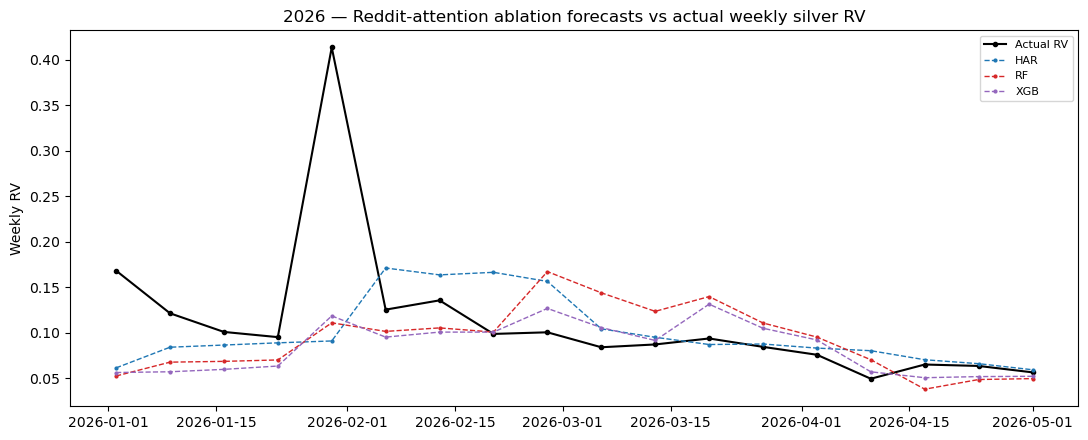

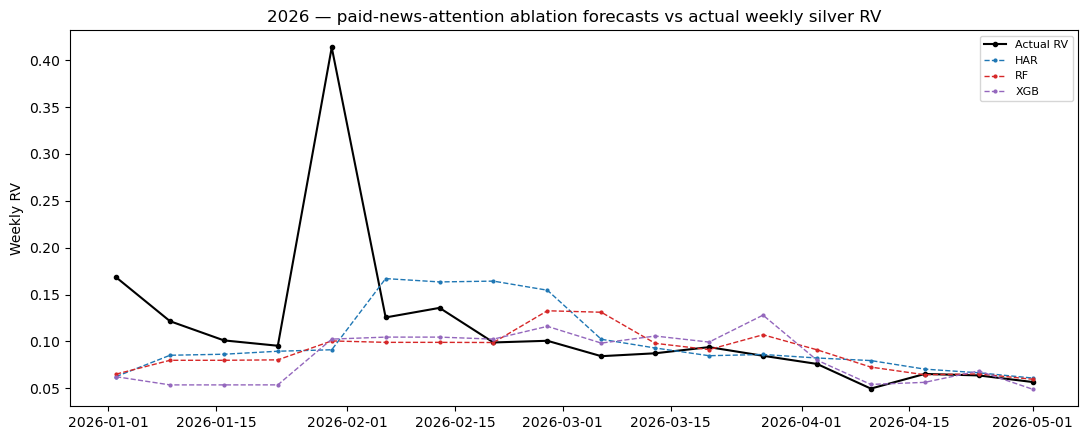

In [7]:
sent_preds = {
    'HAR': pd.read_csv(f'{PROC}/pred_har_sentiment_volatility.csv', parse_dates=['Date']).set_index('Date'),
    'RF':  pd.read_csv(f'{PROC}/pred_rf_sentiment_volatility.csv',  parse_dates=['Date']).set_index('Date'),
    'XGB': pd.read_csv(f'{PROC}/pred_xgb_sentiment_volatility.csv', parse_dates=['Date']).set_index('Date'),
}

def plot_attention_zoom(kind, title):
    cols = {
        'HAR': f'HAR+{kind}',
        'RF':  f'RF (HAR+{kind})',
        'XGB': f'XGB (HAR+{kind})',
    }
    zoom = sent_preds['HAR'][['actual']].copy()
    for fam, col in cols.items():
        zoom[fam] = sent_preds[fam][col]
    zoom = zoom.loc['2026-01-01':].dropna()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(zoom.index, zoom['actual'], 'k-', lw=1.5, marker='o', ms=3, label='Actual RV')
    for col, c in zip(['HAR', 'RF', 'XGB'], ['#1f77b4', '#d62728', '#9467bd']):
        ax.plot(zoom.index, zoom[col], '--', lw=1, marker='.', ms=4, color=c, label=col)
    ax.set_title(title)
    ax.set_ylabel('Weekly RV')
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

plot_attention_zoom('RedditAttention', '2026 — Reddit-attention ablation forecasts vs actual weekly silver RV')
plot_attention_zoom('PaidAttention',   '2026 — paid-news-attention ablation forecasts vs actual weekly silver RV')


## 7. Selected attention-rung ranking

A compact ranking of the pre-specified rows used in the volatility story: each model's
HAR-feature baseline, plus Reddit attention and paid-news attention. The ranking metric is
mean **QLIKE** loss, because QLIKE is the primary volatility-forecasting loss used in the
DM tests above; RMSE, MAE, $R^2$ and DCA are shown as secondary diagnostics.


In [8]:
def mean_qlike(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred   = np.asarray(pred, dtype=float)
    mask = np.isfinite(actual) & np.isfinite(pred) & (actual > 0) & (pred > 0)
    r = (actual[mask] ** 2) / (pred[mask] ** 2)
    return float(np.mean(r - np.log(r) - 1.0))

def local_dca(actual, pred, prev):
    actual = np.asarray(actual, dtype=float)
    pred   = np.asarray(pred, dtype=float)
    prev   = np.asarray(prev, dtype=float)
    a = np.log(actual) - np.log(prev)
    p = np.log(pred) - np.log(prev)
    mask = np.isfinite(a) & np.isfinite(p)
    return float(np.mean(np.sign(a[mask]) == np.sign(p[mask])))

selected = [
    ('HAR', 'HAR baseline', 'HAR'),
    ('HAR', 'Reddit attention', 'HAR+RedditAttention'),
    ('HAR', 'Paid attention', 'HAR+PaidAttention'),
    ('RF',  'HAR baseline', 'RF (HAR)'),
    ('RF',  'Reddit attention', 'RF (HAR+RedditAttention)'),
    ('RF',  'Paid attention', 'RF (HAR+PaidAttention)'),
    ('XGB', 'HAR baseline', 'XGB (HAR)'),
    ('XGB', 'Reddit attention', 'XGB (HAR+RedditAttention)'),
    ('XGB', 'Paid attention', 'XGB (HAR+PaidAttention)'),
]

rows = []
for fam, rung, col in selected:
    df = sent_preds[fam][['actual', 'naive', col]].dropna()
    actual = df['actual'].values
    pred = df[col].values
    prev = df['naive'].values
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)
    rows.append({
        'family': fam,
        'rung': rung,
        'model': col,
        'qlike': mean_qlike(actual, pred),
        'rmse': float(np.sqrt(np.mean((actual - pred) ** 2))),
        'mae': float(np.mean(np.abs(actual - pred))),
        'r2': float(1 - ss_res / ss_tot),
        'dca': local_dca(actual, pred, prev),
        'n': len(df),
    })

rank_tbl = pd.DataFrame(rows).sort_values('qlike').reset_index(drop=True)
rank_tbl.insert(0, 'rank', np.arange(1, len(rank_tbl) + 1))
rank_tbl = rank_tbl.merge(
    sent_all[['family', 'model', 'dm_qlike', 'dm_qlike_p', 'winner_dm_qlike']],
    on=['family', 'model'], how='left'
)
rank_tbl.to_csv(f'{PROC}/metrics_attention_selected_ranking.csv', index=False)
rank_tbl.round({'qlike': 5, 'rmse': 5, 'mae': 5, 'r2': 5, 'dca': 5, 'dm_qlike': 3, 'dm_qlike_p': 3})


,rank,family,rung,model,qlike,rmse,mae,r2,dca,n,dm_qlike,dm_qlike_p,winner_dm_qlike
0,1,HAR,Paid attention,HAR+PaidAttention,0.50448,0.03172,0.01605,0.30723,0.71839,174,-3.325,0.001,HAR+PaidAttention
1,2,XGB,Reddit attention,XGB (HAR+RedditAttention),0.51820,0.03099,0.01737,0.33877,0.68391,174,-2.359,0.018,XGB (HAR+RedditAttention)
2,3,HAR,Reddit attention,HAR+RedditAttention,0.52165,0.03191,0.01621,0.29859,0.70690,174,-2.596,0.009,HAR+RedditAttention
3,4,RF,HAR baseline,RF (HAR),0.52218,0.03168,0.01662,0.30881,0.70690,174,NaN,NaN,NaN
4,5,RF,Paid attention,RF (HAR+PaidAttention),0.52788,0.03133,0.01694,0.32393,0.68391,174,0.233,0.816,tie
5,6,HAR,HAR baseline,HAR,0.52891,0.03205,0.01627,0.29263,0.70690,174,NaN,NaN,NaN
6,7,XGB,Paid attention,XGB (HAR+PaidAttention),0.54578,0.03205,0.01752,0.29241,0.69540,174,-2.197,0.028,XGB (HAR+PaidAttention)
7,8,RF,Reddit attention,RF (HAR+RedditAttention),0.59587,0.03249,0.01835,0.27310,0.69540,174,1.974,0.048,RF (HAR)
8,9,XGB,HAR baseline,XGB (HAR),0.66697,0.03329,0.01900,0.23675,0.66092,174,NaN,NaN,NaN


## 8. Conclusion

Read the tables above against these questions:

1. **Does HAR-RV beat Naïve on RMSE?** If yes, silver volatility has predictable
   structure beyond a pure random walk — consistent with the equity/FX literature.
2. **Does GARCH(1,1) beat HAR-RV?** On weekly equity-like series HAR usually wins;
   GARCH is parametric and assumes Gaussian innovations.
3. **Do nonlinear RF/XGB models beat OLS-HAR on the same information set?** Read the
   headline `RF (HAR)` / `XGB (HAR)` rows against `HAR-RV`; this is the clean estimator
   comparison because all three use the same HAR lags.
4. **Do the EXOG cross-asset RVs help?** Read `HAR+EXOG`, `RF (HAR+EXOG)` and
   `XGB (HAR+EXOG)` in the ablation table. These rows test spillover separately from
   the headline model-class comparison.
5. **DCA** — vol rising vs falling is the trader-relevant binary. DCA > 0.55 is already
   useful for risk-management timing. (The Naïve DCA is ≈ 0 by construction: predicting
   last week's RV implies *no* change, so it can never call a direction.)
6. **Statistical significance** — read the **QLIKE-DM** row, not the squared-error row.
   Squared-error DM is near-powerless on this heavy-tailed RV target (one 2026 week
   carries ~80 % of the loss differential), so an RMSE improvement that is real and
   steady can still fail an MSE-DM test. QLIKE — the proxy-robust loss standard in the
   volatility literature — is the test to report; MSE-DM is kept only as a reference
   that demonstrates the heavy-tail problem.
7. **Does sentiment help?** The §5 ablation — read `dm_qlike` per family against bare
   `HAR` / `RF (HAR)` / `XGB (HAR)`. A negative, significant `dm_qlike` means
   the news→volatility channel is live for silver; a null says public sentiment adds
   nothing once the model's own-history information is in — a clean
   semi-strong-form companion to the returns side. (Note that on this sample the HAR
   block's own-history baseline is the *only* informative control — `HAR+EXOG` is
   itself worse than bare HAR.)